In [3]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**17            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Euler vs Milstein comparison
This notebook compares the Euler (weak Euler) and Milstein-like scheme implemented in `lib.MonteCarloSimulation`.
We compute (1) pathwise differences at the current `M`, and (2) an estimate of the strong error by comparing coarse time-grids to a fine Milstein reference using the same Brownian paths.

In [ ]:
# Strong convergence experiment: compare coarse schemes to a fine Milstein reference.
# We generate fine increments Z_fine and aggregate to coarser time-grids so Brownian paths are consistent.
N = 2**16             # number of paths (adjustable)
M_ref = 2048*2*2         # fine reference mesh (must be multiple of coarse meshes)
sim_ref = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_ref)
# draw fine standard normals (shape N x M_ref)
Z_fine = sim_ref.draw_pseudo_random_numbers(sim_ref.base_seed, N, M_ref)
dt_ref = T / M_ref
dW_fine = np.sqrt(dt_ref) * Z_fine
# list of coarse meshes to test (must divide M_ref)
M_list = [8, 16, 32, 64, 128, 256, 512, 1024]
M_list = [m for m in M_list if M_ref % m == 0]
errors_euler = []
errors_mil = []
dts = []
S_eT_list = []
S_mT_list = []
# compute fine reference terminal prices using Milstein-like scheme
Sref = sim_ref.sim_CEV_paths(N, Z_fine, euler=False)
Sref_T = Sref[:, -1]
for M_coarse in M_list:
    block = M_ref // M_coarse
    # aggregate dW_fine in blocks -> dW_coarse shape (N, M_coarse)
    dW_coarse = dW_fine.reshape(N, M_coarse, block).sum(axis=2)
    dt_coarse = T / M_coarse
    Z_coarse = dW_coarse / np.sqrt(dt_coarse)
    # create sim instance for coarse grid (so self.M matches Z length)
    sim_coarse = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_coarse)
    # Euler on coarse grid
    S_e = sim_coarse.sim_CEV_paths(N, Z_coarse, euler=True)
    # Milstein-like on coarse grid
    S_m = sim_coarse.sim_CEV_paths(N, Z_coarse, euler=False)
    # terminal values
    SeT = S_e[:, -1]
    SmT = S_m[:, -1]
    # store terminal arrays for later MC-noise analysis
    S_eT_list.append(SeT)
    S_mT_list.append(SmT)
    # compute L2 (root mean square) strong error against fine Milstein reference
    err_e = np.sqrt(((SeT - Sref_T)**2).mean())
    err_m = np.sqrt(((SmT - Sref_T)**2).mean())
    errors_euler.append(err_e)
    errors_mil.append(err_m)
    dts.append(dt_coarse)
    print(f'M={M_coarse:5d}, dt={dt_coarse:.3e}, Euler L2={err_e:.3e}, Milstein L2={err_m:.3e}')
# convert to arrays for plotting/fitting
dts = np.array(dts)
errors_euler = np.array(errors_euler)
errors_mil = np.array(errors_mil)
# keep terminal arrays as a numpy array of shape (len(M_list), N) for analysis
S_eT_array = np.vstack([arr for arr in S_eT_list])  # shape (K, N)
S_mT_array = np.vstack([arr for arr in S_mT_list])  # shape (K, N)
# Fit slopes in log-log (ignore leading coarse points if noisy)
fit_idx = slice(None)
slope_e, intercept_e = np.polyfit(np.log(dts[fit_idx]), np.log(errors_euler[fit_idx]), 1)
slope_m, intercept_m = np.polyfit(np.log(dts[fit_idx]), np.log(errors_mil[fit_idx]), 1)
print()
print(f'Fitted slopes (log-error vs log-dt): Euler {slope_e:.3f}, Milstein {slope_m:.3f}')

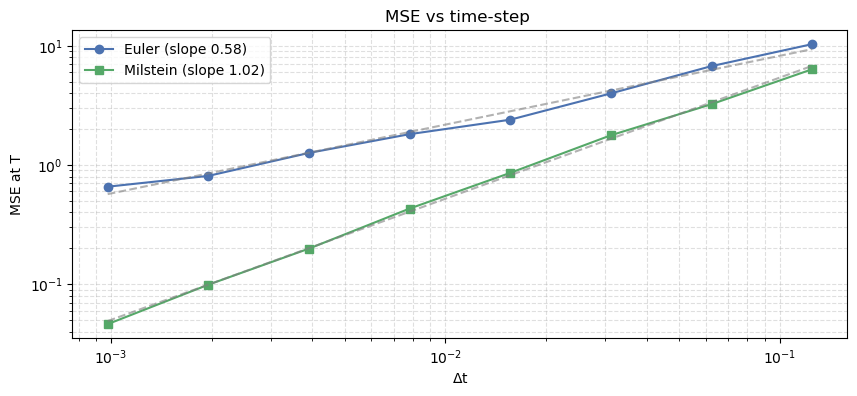

In [ ]:
# Plot results (log-log)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.loglog(dts, errors_euler, '-o', label=f'Euler (slope {slope_e:.2f})',color='#4C72B0')
plt.loglog(dts, errors_mil, '-s', label=f'Milstein (slope {slope_m:.2f})',color='#55A868')
# reference lines showing expected slopes: 0.5 and 1.0 (scaled)
# choose scale so they appear near the data
ref_x = np.array([dts.min(), dts.max()])
ref_e = np.exp(intercept_e) * ref_x**slope_e
ref_m = np.exp(intercept_m) * ref_x**slope_m
plt.loglog(ref_x, ref_e, '--', color='gray', alpha=0.6)
plt.loglog(ref_x, ref_m, '--', color='gray', alpha=0.6)
plt.xlabel('$\Delta$t')
plt.ylabel('MSE at T')
plt.title('MSE vs time-step ')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.savefig(os.path.join('../Graphs', 'EUMIL.png'), dpi=300)
plt.show()